# RVC-Based Emotion Style Transfer for Hindi SER

**Goal:** Train one RVC model per emotion class, then use each model to convert
neutral speech into that emotion's acoustic style — generating high-quality synthetic data.

**Why RVC works better than StarGAN here:**
- Built on HuBERT (pretrained on 94k hrs multilingual audio) → language independent
- Designed for small datasets (works well with < 10 minutes of audio per class)
- HiFi-GAN vocoder → no WORLD artifacts, production-quality output
- Training per emotion = ~15–30 mins each on RTX 4000 Ada

**Strategy:**
```
Train 8 RVC models (one per emotion, trained on that emotion's 400 real samples)
        ↓
Convert all neutral samples → each of the other 7 emotions
        ↓
400 neutral × 7 target emotions = 2,800 new synthetic samples
(optionally repeat for other source emotions)
```

**Dataset structure expected:**
```
flattened_dataset/
  anger/   disgust/  fear/  happy/
  neutral/ sad/      sarcastic/ surprise/
```

In [6]:
import os, urllib.request

dst_dir = "./hub/models--lj1995--VoiceConversionWebUI/snapshots/b2c8cae96e3b05de46d36c5ef9970ef6cbccafba"
os.makedirs(dst_dir, exist_ok=True)

url = "https://huggingface.co/lj1995/VoiceConversionWebUI/resolve/main/rmvpe.pt"
dst = os.path.join(dst_dir, "rmvpe.pt")

urllib.request.urlretrieve(url, dst)

print("RMVPE model downloaded.")

RMVPE model downloaded.


## Step 0 — Install Dependencies

In [1]:
import sys, subprocess

# av — needs pre-built binary on Windows
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'av', '--prefer-binary', '-q'], check=False)

# torchcodec ships a broken DLL on some Windows setups — uninstall it
# zerorvc does not need it; av handles audio I/O instead
subprocess.run([sys.executable, '-m', 'pip', 'uninstall', 'torchcodec', '-y'],
               capture_output=True)  # silent — ok if not installed

# Core packages
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'zerorvc', 'transformers', 'accelerate',
                'datasets', 'soundfile', 'librosa',
                'tqdm', 'matplotlib', 'seaborn', '-q'], check=True)

# Verify
import importlib
all_ok = True
for pkg in ['zerorvc', 'transformers', 'accelerate', 'datasets', 'soundfile', 'librosa', 'av']:
    try:
        importlib.import_module(pkg)
        print(f'  OK  {pkg}')
    except ImportError as e:
        print(f'  FAILED  {pkg}: {e}')
        all_ok = False

print('\nAll OK — restart kernel now' if all_ok else '\nSome packages failed — check above')


c:\Users\Student\anaconda3\envs\torch_gpu\lib\site-packages\zerorvc\dataset.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


  OK  zerorvc
  OK  transformers
  OK  accelerate
  OK  datasets
  OK  soundfile
  OK  librosa
  OK  av

All OK — restart kernel now


## Step 1 — Imports & Config

In [1]:
import os, glob, shutil, warnings
os.environ["TRANSFORMERS_CACHE"] = os.path.abspath("./hub")
os.environ["HF_HOME"] = os.path.abspath("./")
import numpy as np
import soundfile as sf
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import Audio, display
from datasets import Dataset, Audio as HFAudio
from zerorvc import prepare, RVCTrainer, RVC
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
FLAT_DATA_DIR = 'flattened_dataset'   # <── UPDATE if needed
RVC_MODELS_DIR = 'rvc_models'         # trained .pth saved here per emotion
SYNTH_DIR      = 'rvc_synthetic'      # generated wavs
FINAL_DIR      = 'final_dataset_rvc'  # real + synthetic combined

for d in [RVC_MODELS_DIR, SYNTH_DIR, FINAL_DIR]:
    os.makedirs(d, exist_ok=True)

# ── Audio config ───────────────────────────────────────────────────────────
SAMPLE_RATE = 16000

# ── Training config ────────────────────────────────────────────────────────
EPOCHS     = 100    # per emotion model — increase to 200 if quality is poor
BATCH_SIZE = 8

# ── Emotions ───────────────────────────────────────────────────────────────
EMOTIONS = ['anger', 'disgust', 'fear', 'happy',
            'neutral', 'sad', 'sarcastic', 'surprise']

# Source emotion to convert FROM (neutral is best — most natural baseline)
SOURCE_EMOTIONS = ['neutral']   # add more e.g. ['neutral', 'sad'] for more data

import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print(f'Emotions: {EMOTIONS}')
print(f'Source emotion(s) for conversion: {SOURCE_EMOTIONS}')

c:\Users\Student\anaconda3\envs\torch_gpu\lib\site-packages\transformers\utils\hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
c:\Users\Student\anaconda3\envs\torch_gpu\lib\site-packages\zerorvc\dataset.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


Device: cuda
Emotions: ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
Source emotion(s) for conversion: ['neutral']


In [2]:
import shutil, os

src = "./contentvec_model"
dst = "./hub/models--safe-models--ContentVec/snapshots/local"

os.makedirs(dst, exist_ok=True)

for f in os.listdir(src):
    src_path = os.path.join(src, f)
    dst_path = os.path.join(dst, f)

    if os.path.isfile(src_path):   # skip directories like .cache
        shutil.copy(src_path, dst_path)

print("ContentVec installed locally.")

ContentVec installed locally.


## Step 2 — Verify Dataset & Explore


In [3]:
print('Dataset summary:')
print(f'{"Emotion":<12}  {"Files":>6}  {"Total mins":>10}')
print('─' * 34)
for emotion in EMOTIONS:
    wavs = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, emotion, '*.wav')))
    if not wavs:
        print(f'  WARNING: no files found in {FLAT_DATA_DIR}/{emotion}')
        continue
    # Sample a few to estimate duration
    durations = [librosa.get_duration(path=w) for w in wavs[:10]]
    avg_dur   = np.mean(durations)
    total_min = avg_dur * len(wavs) / 60
    print(f'{emotion:<12}  {len(wavs):>6}  {total_min:>10.1f}')
print('\nSample filename:', os.path.basename(wavs[0]))

Dataset summary:
Emotion        Files  Total mins
──────────────────────────────────
anger            401        21.9
disgust          401        21.5
fear             401        27.0
happy            401        26.7
neutral          401        23.9
sad              401        26.4
sarcastic        401        25.9
surprise         401        24.0

Sample filename: 1_session1_1.1.surprise-01.wav


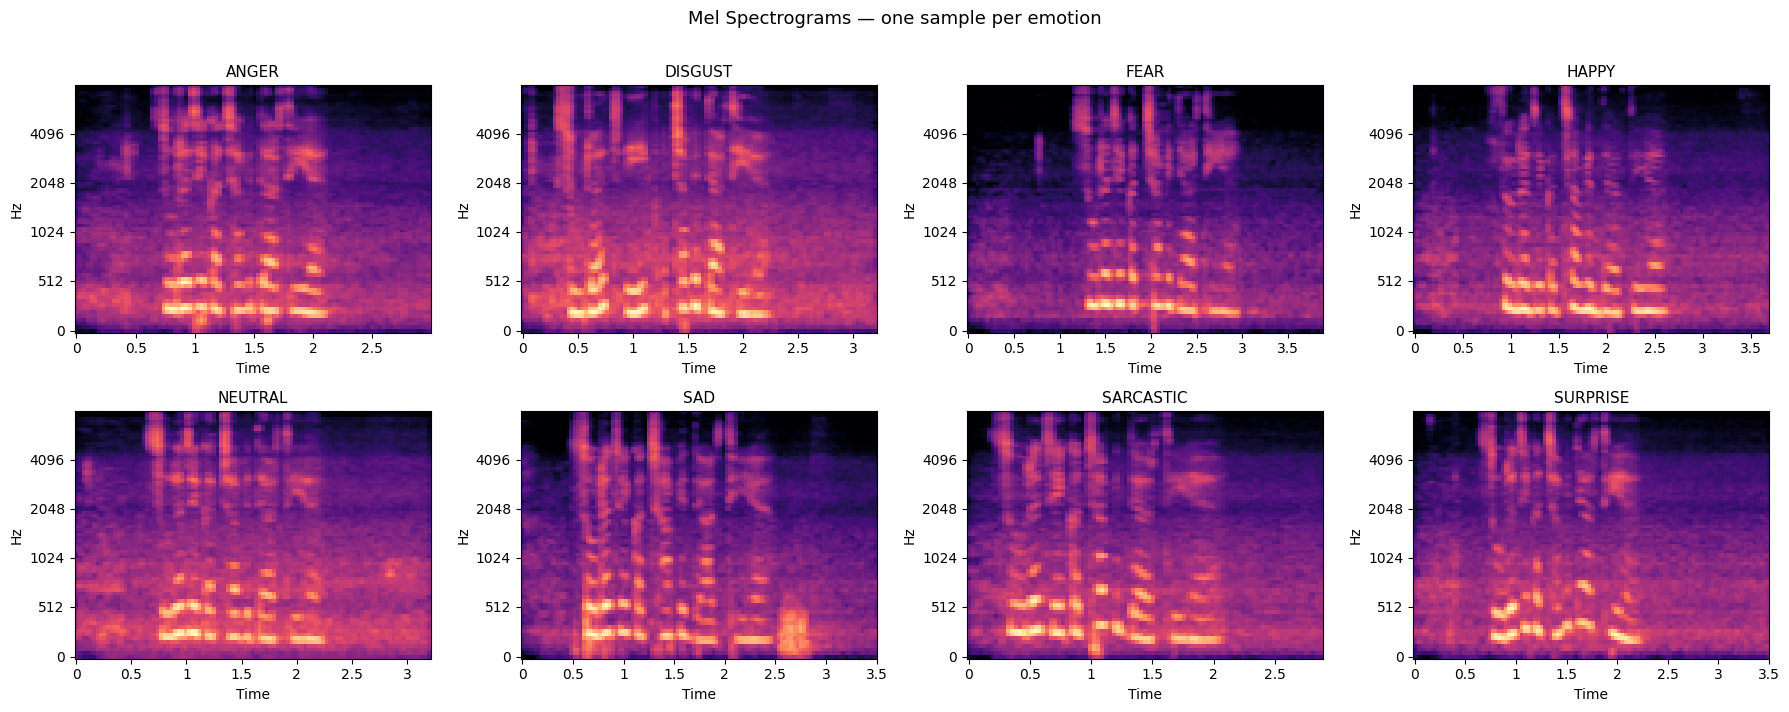

In [4]:
# Mel spectrogram per emotion
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()
for i, emotion in enumerate(EMOTIONS):
    fp  = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, emotion, '*.wav')))[0]
    y, sr = librosa.load(fp, sr=SAMPLE_RATE)
    mel   = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                              sr=sr, x_axis='time', y_axis='mel',
                              ax=axes[i], cmap='magma')
    axes[i].set_title(emotion.upper(), fontsize=11)
plt.suptitle('Mel Spectrograms — one sample per emotion', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## Step 3 — Prepare Datasets for RVC

ZeroRVC expects HuggingFace `Dataset` objects with an `audio` column.
We prepare one dataset per emotion class.

In [5]:
def get_emotion_wav_dir(emotion, flat_dir=FLAT_DATA_DIR):
    """Returns the path to the wav folder for an emotion — what zerorvc.prepare() expects."""
    return os.path.join(flat_dir, emotion)


# Prepare all emotion datasets
# zerorvc.prepare() takes a DIRECTORY PATH, scans for audio files,
# extracts HuBERT + RMVPE features and returns a HuggingFace Dataset
prepared_datasets = {}
from transformers import HubertModel

hubert_path = "./contentvec_model"

for emotion in tqdm(EMOTIONS, desc='Preparing datasets'):
    cache_path = os.path.join(RVC_MODELS_DIR, f'{emotion}_prepared')

    if os.path.exists(cache_path):
        from datasets import load_from_disk
        prepared_datasets[emotion] = load_from_disk(cache_path)
        print(f'  {emotion}: loaded from cache ({len(prepared_datasets[emotion])} samples)')
    else:
        wav_dir = get_emotion_wav_dir(emotion)
        print(f'  {emotion}: preparing from {wav_dir} ...')

        prepared_ds = prepare(
            wav_dir,
            hubert=hubert_path
        )

        prepared_ds.save_to_disk(cache_path)
        prepared_datasets[emotion] = prepared_ds
        print(f'  {emotion}: done ({len(prepared_ds)} samples)')

print('\nAll datasets prepared.')


Preparing datasets:   0%|          | 0/8 [00:00<?, ?it/s]

  anger: loaded from cache (1 samples)
  disgust: loaded from cache (1 samples)
  fear: loaded from cache (1 samples)
  happy: loaded from cache (1 samples)
  neutral: loaded from cache (1 samples)
  sad: loaded from cache (1 samples)
  sarcastic: loaded from cache (1 samples)
  surprise: loaded from cache (1 samples)

All datasets prepared.


## Step 4 — Train RVC Models

We train the **pilot model first** (neutral) so you can verify quality
before committing to the full ~2–4 hour training run.

**Cell 4a** — define training function  
**Cell 4b** — train pilot model only (~15–30 mins)  
**Cell 5** — spot-check pilot quality  
**Cell 4c** — train remaining 7 models (run only if pilot looks good)


In [6]:
def train_emotion_model(emotion, prepared_ds, epochs=50, batch_size=4):

    model_dir = os.path.join(RVC_MODELS_DIR, emotion)
    os.makedirs(model_dir, exist_ok=True)

    split = prepared_ds["train"].train_test_split(test_size=0.1, seed=42)

    trainer = RVCTrainer(
        model_dir,
        dataset_train=split["train"],
        dataset_test=split["test"],
    )

    trainer.train(epochs=epochs, batch_size=batch_size)


def load_trained_models(emotions):
    """Scan RVC_MODELS_DIR and return {emotion: latest_checkpoint_path}."""
    found = {}
    for emo in emotions:
        ckpts = sorted(glob.glob(os.path.join(RVC_MODELS_DIR, emo, '*.pth')))
        if ckpts:
            found[emo] = ckpts[-1]
    return found

print('train_emotion_model() and load_trained_models() defined.')


train_emotion_model() and load_trained_models() defined.


In [7]:
# ── Train PILOT model (neutral) ───────────────────────────────────────────
# We train only the neutral model first so you can test quality before
# committing to training all 8 models (~2–4 hours total).
#
# neutral is the best pilot choice — it is the source emotion we convert FROM,
# so its quality directly reflects what the full pipeline will produce.

PILOT_EMOTION = 'neutral'   # change if you want to test a different emotion first

pilot_dir    = os.path.join(RVC_MODELS_DIR, PILOT_EMOTION)
pilot_ckpts  = sorted(glob.glob(os.path.join(pilot_dir, '*.pth')))

if pilot_ckpts:
    print(f'Pilot model already exists: {pilot_ckpts[-1]}')
    print('Skip to the spot-check cell to test it.')
else:
    print(f'Training pilot model: {PILOT_EMOTION} ...')
    train_emotion_model(PILOT_EMOTION, prepared_datasets[PILOT_EMOTION])
    pilot_ckpts = sorted(glob.glob(os.path.join(pilot_dir, '*.pth')))
    print(f'Done → {pilot_ckpts[-1]}')

trained_models = load_trained_models(EMOTIONS)
print(f'\nModels trained so far: {list(trained_models.keys())}')


Pilot model already exists: rvc_models\neutral\G_latest.pth
Skip to the spot-check cell to test it.

Models trained so far: ['anger', 'disgust', 'fear', 'neutral']


## Step 5 — Spot-Check Pilot Model

Test the pilot model before training the rest.
**Audio should sound like clean speech** — no robot/noise artifacts.
If it does, run Cell 4c to train the remaining 7 models.

Loading weights from local directory
Loaded: anger
Loading weights from local directory
Loaded: disgust
Loading weights from local directory
Loaded: fear
Loading weights from local directory
Loaded: neutral

Spot-check: anger → neutral
Source file: 1_session1_1.1.anger-01.wav

Original (anger):



Converted → neutral:


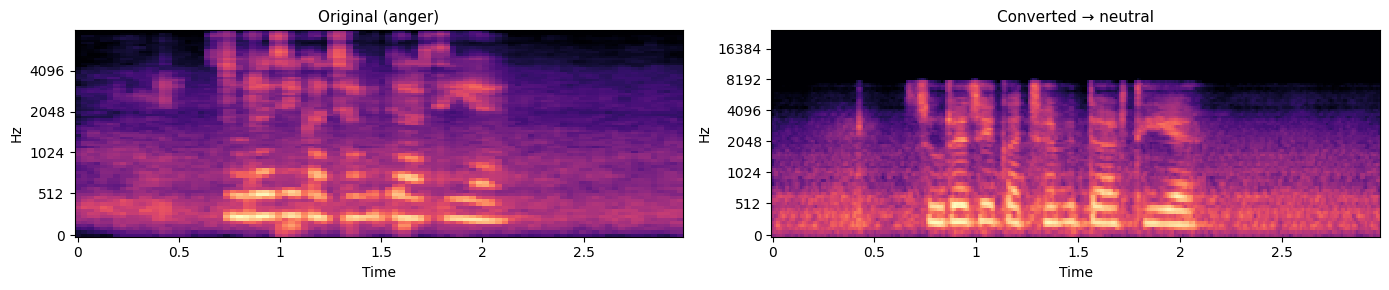


✅ If the converted audio sounds like clean speech, proceed to train remaining models.
❌ If it sounds noisy/robotic, try increasing EPOCHS in Step 1 config and re-run pilot training.


In [8]:
# ── Load only the pilot model for spot-check ──────────────────────────────
rvc_models = {}
for emotion, model_path in trained_models.items():
    rvc_models[emotion] = RVC.from_pretrained(os.path.dirname(model_path))
    print(f'Loaded: {emotion}')

# We can only convert INTO emotions we have models for.
# At pilot stage that is just: neutral
# The pilot model converts OTHER audio to sound like the pilot emotion.
# To test the reverse (neutral → anger), we need the anger model.
# So for the pilot test we use the neutral model to convert an anger file → neutral.
# This still verifies the pipeline quality end-to-end.

pilot_src_emotion = [e for e in EMOTIONS if e != PILOT_EMOTION][0]  # e.g. anger
test_wav = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, pilot_src_emotion, '*.wav')))[0]

print(f'\nSpot-check: {pilot_src_emotion} → {PILOT_EMOTION}')
print(f'Source file: {os.path.basename(test_wav)}')
print(f'\nOriginal ({pilot_src_emotion}):')
display(Audio(test_wav))

samples = rvc_models[PILOT_EMOTION].convert(test_wav)
sr_out  = rvc_models[PILOT_EMOTION].sr
print(f'\nConverted → {PILOT_EMOTION}:')
display(Audio(samples, rate=sr_out))

# Spectrogram comparison
y_orig, _ = librosa.load(test_wav, sr=SAMPLE_RATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
for ax, (sig, sr_sig, title) in zip(axes, [
        (y_orig,                  SAMPLE_RATE, f'Original ({pilot_src_emotion})'),
        (samples.astype(np.float32), sr_out,   f'Converted → {PILOT_EMOTION}')]):
    mel = librosa.feature.melspectrogram(y=sig, sr=sr_sig, n_mels=80)
    librosa.display.specshow(librosa.power_to_db(mel, ref=np.max),
                              sr=sr_sig, x_axis='time', y_axis='mel',
                              ax=ax, cmap='magma')
    ax.set_title(title, fontsize=11)
plt.tight_layout()
plt.show()

print('\n✅ If the converted audio sounds like clean speech, proceed to train remaining models.')
print('❌ If it sounds noisy/robotic, try increasing EPOCHS in Step 1 config and re-run pilot training.')


In [9]:
# ── Train REMAINING 7 models ──────────────────────────────────────────────
# Run this cell only after you are happy with the pilot spot-check above.
# Already-trained models are skipped automatically.

for emotion in EMOTIONS:
    if emotion in trained_models:
        print(f'{emotion}: already trained — skipping')
        continue
    print(f'\nTraining: {emotion} ...')
    train_emotion_model(emotion, prepared_datasets[emotion])
    print(f'{emotion}: done')

trained_models = load_trained_models(EMOTIONS)
print(f'\nAll trained models ({len(trained_models)}/8):')
for emo, path in trained_models.items():
    print(f'  {emo:<12}: {os.path.basename(path)}')


anger: already trained — skipping
disgust: already trained — skipping
fear: already trained — skipping

Training: happy ...


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Epoch 1:   0%|          | 0/104 [00:00<?, ?it/s]

Testing epoch 1:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/104 [00:00<?, ?it/s]

...

Epoch 49:   0%|          | 0/110 [00:00<?, ?it/s]

Testing epoch 49:   0%|          | 0/13 [00:00<?, ?it/s]

Epoch 50:   0%|          | 0/110 [00:00<?, ?it/s]

Testing epoch 50:   0%|          | 0/13 [00:00<?, ?it/s]

surprise: done

All trained models (8/8):
  anger       : G_latest.pth
  disgust     : G_latest.pth
  fear        : G_latest.pth
  happy       : G_latest.pth
  neutral     : G_latest.pth
  sad         : G_latest.pth
  sarcastic   : G_latest.pth
  surprise    : G_latest.pth


## Step 6 — Full Synthetic Data Generation

Convert all source emotion files to all other target emotions.

Default config (SOURCE_EMOTIONS = ['neutral']):
```
400 neutral files × 7 target emotions = 2,800 synthetic files
```

Add more source emotions in Step 1 config to generate more data.

In [10]:
from concurrent.futures import ThreadPoolExecutor, as_completed

# RVC inference is GPU-accelerated but not easily batchable across files
# Use thread pool for file I/O parallelism around sequential GPU inference
NUM_IO_WORKERS = 4

failed    = []
generated = 0

for src_emo in SOURCE_EMOTIONS:
    src_wavs = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, src_emo, '*.wav')))
    print(f'\nSource: {src_emo} ({len(src_wavs)} files)')

    for tgt_emo in EMOTIONS:
        if tgt_emo == src_emo:
            continue

        out_dir = os.path.join(SYNTH_DIR, tgt_emo)
        os.makedirs(out_dir, exist_ok=True)

        model = rvc_models[tgt_emo]

        todo = []
        for wp in src_wavs:
            stem = os.path.splitext(os.path.basename(wp))[0]
            op   = os.path.join(out_dir, f'rvc_{src_emo}2{tgt_emo}_{stem}.wav')
            if os.path.exists(op):
                generated += 1
            else:
                todo.append((wp, op))

        if not todo:
            print(f'  {src_emo}→{tgt_emo}: all done (skipping)')
            continue

        for wav_path, out_path in tqdm(todo, desc=f'{src_emo}→{tgt_emo}', leave=False):
            try:
                samples = model.convert(wav_path)
                sf.write(out_path, samples, model.sr)
                generated += 1
            except Exception as e:
                failed.append((wav_path, tgt_emo, str(e)))

        print(f'  {src_emo}→{tgt_emo}: done')

print(f'\nTotal generated: {generated}  |  Failed: {len(failed)}')
for item in failed[:10]:
    print(' ', item)


Source: neutral (401 files)


neutral→anger:   0%|          | 0/401 [00:00<?, ?it/s]

  neutral→anger: done


neutral→disgust:   0%|          | 0/401 [00:00<?, ?it/s]

  neutral→disgust: done


neutral→fear:   0%|          | 0/401 [00:00<?, ?it/s]

  neutral→fear: done


KeyError: 'happy'

## Step 7 — Build Final Dataset (Real + RVC Synthetic)

In [ ]:
for emotion in EMOTIONS:
    # Real data
    dst_real = os.path.join(FINAL_DIR, 'real', emotion)
    os.makedirs(dst_real, exist_ok=True)
    for wav in glob.glob(os.path.join(FLAT_DATA_DIR, emotion, '*.wav')):
        shutil.copy(wav, dst_real)

    # Synthetic data
    dst_synth = os.path.join(FINAL_DIR, 'synthetic', emotion)
    os.makedirs(dst_synth, exist_ok=True)
    for wav in glob.glob(os.path.join(SYNTH_DIR, emotion, '*.wav')):
        shutil.copy(wav, dst_synth)

# Summary table
print(f'\n{"Emotion":<12}  {"Real":>6}  {"Synthetic":>10}  {"Total":>7}')
print('─' * 42)
gr = gs = 0
for emotion in EMOTIONS:
    r = len(glob.glob(os.path.join(FINAL_DIR, 'real',      emotion, '*.wav')))
    s = len(glob.glob(os.path.join(FINAL_DIR, 'synthetic', emotion, '*.wav')))
    gr += r; gs += s
    synth_tag = '⚠️ no synth' if s == 0 else ''
    print(f'{emotion:<12}  {r:>6}  {s:>10}  {r+s:>7}  {synth_tag}')
print('─' * 42)
print(f'{"TOTAL":<12}  {gr:>6}  {gs:>10}  {gr+gs:>7}')

## Step 8 — Quality Evaluation

In [ ]:
# Visual: compare spectrograms of real vs synthetic for each target emotion
fig, axes = plt.subplots(len(EMOTIONS), 2, figsize=(14, len(EMOTIONS) * 2.5))

src_emo   = SOURCE_EMOTIONS[0]
src_sample = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, src_emo, '*.wav')))[0]
src_stem   = os.path.splitext(os.path.basename(src_sample))[0]

for i, tgt_emo in enumerate(EMOTIONS):
    # Real sample of target emotion
    real_wav = sorted(glob.glob(os.path.join(FLAT_DATA_DIR, tgt_emo, '*.wav')))[0]
    y_real, _ = librosa.load(real_wav, sr=SAMPLE_RATE)
    mel_real  = librosa.feature.melspectrogram(y=y_real, sr=SAMPLE_RATE, n_mels=80)

    librosa.display.specshow(librosa.power_to_db(mel_real, ref=np.max),
                              sr=SAMPLE_RATE, ax=axes[i, 0], cmap='magma')
    axes[i, 0].set_title(f'REAL — {tgt_emo}', fontsize=9)
    axes[i, 0].set_ylabel('')

    # Corresponding synthetic sample (if it exists)
    synth_pattern = os.path.join(FINAL_DIR, 'synthetic', tgt_emo,
                                  f'rvc_{src_emo}2{tgt_emo}_{src_stem}.wav')
    synth_matches = glob.glob(synth_pattern)
    if synth_matches:
        y_syn, _ = librosa.load(synth_matches[0], sr=SAMPLE_RATE)
        mel_syn  = librosa.feature.melspectrogram(y=y_syn, sr=SAMPLE_RATE, n_mels=80)
        librosa.display.specshow(librosa.power_to_db(mel_syn, ref=np.max),
                                  sr=SAMPLE_RATE, ax=axes[i, 1], cmap='magma')
        axes[i, 1].set_title(f'SYNTHETIC — {src_emo}→{tgt_emo}', fontsize=9)
    else:
        axes[i, 1].text(0.5, 0.5, 'No synthetic\n(not in source emotions)',
                         ha='center', va='center', transform=axes[i, 1].transAxes)
        axes[i, 1].set_title(f'SYNTHETIC — {tgt_emo}', fontsize=9)

plt.suptitle(f'Real vs RVC Synthetic — source: {src_emo}', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('rvc_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Audio playback comparison for each converted emotion
print(f'Source ({src_emo}):')
display(Audio(src_sample))

for tgt_emo in EMOTIONS:
    if tgt_emo == src_emo:
        continue
    synth_wavs = sorted(glob.glob(
        os.path.join(FINAL_DIR, 'synthetic', tgt_emo, f'rvc_{src_emo}2{tgt_emo}_*.wav')))
    if synth_wavs:
        print(f'\nConverted → {tgt_emo}:')
        display(Audio(synth_wavs[0]))

## Step 9 — Next Steps: Plug into SER Notebook

```python
# In hindi_ser.ipynb — replace load_dataset calls:
X_real,  y_real  = load_dataset('final_dataset_rvc/real')
X_synth, y_synth = load_dataset('final_dataset_rvc/synthetic')
X = np.concatenate([X_real, X_synth])
y = np.concatenate([y_real, y_synth])
```

**Recommended experiment table for your capstone:**

| Experiment | Data | Expected |
|---|---|---|
| Baseline | Real only (3,200) | Reference |
| + Traditional aug | Real + pitch/speed/noise | Small improvement |
| + RVC synthetic | Real + RVC (varies by source) | Best quality synth |
| All combined | Real + trad aug + RVC | Best overall |

**To generate more synthetic data**, add more source emotions to `SOURCE_EMOTIONS` in Step 1:
```python
SOURCE_EMOTIONS = ['neutral', 'sad', 'happy', 'anger']  # converts each to all others
# neutral × 7 + sad × 7 + happy × 7 + anger × 7 = 11,200 synthetic files
```